# Regresión lineal: el modelo más simple y más importante

---

¿Por qué empezar por aquí? Porque la regresión lineal es el *building block* de prácticamente todo el machine learning. Redes neuronales, árboles de decisión, modelos de lenguaje — todos, de una forma u otra, construyen sobre ideas que nacen en este modelo aparentemente simple.

La promesa es directa: dada una serie de datos, encontrar la línea recta (o el hiperplano, si hay más de una variable) que mejor describe la relación entre las entradas y la salida. Suena sencillo, y lo es. Pero entender **cómo** encuentra esa línea y **qué implica** usarla en el mundo real es lo que separa a alguien que aplica herramientas de alguien que entiende lo que está haciendo.

Si entiendes la regresión lineal — su función de coste, cómo se optimiza, qué asume sobre los datos — entiendes los fundamentos de cómo "aprende" una máquina. Todo lo demás es sofisticación sobre estas mismas ideas.

### Contexto histórico

El término **"regresión"** tiene un origen curioso. En 1886, Francis Galton estudió la relación entre la altura de padres e hijos y observó que los hijos de padres muy altos tendían a ser más bajos que sus padres, y viceversa. Llamó a este fenómeno *"regression toward the mean"* — regresión a la media. El nombre se quedó, aunque hoy lo usamos para algo más general: modelar la relación entre variables.

### Referencias

Este notebook sigue de cerca el **Capítulo 4** de *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* de Aurélien Géron (3ª edición, 2022), uno de los mejores libros prácticos para entender ML. Para quienes quieran ir más profundo en la teoría, *The Elements of Statistical Learning* de Hastie, Tibshirani y Friedman (Capítulo 3) es la referencia académica clásica — y está disponible de forma gratuita.

---

In [18]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [19]:
# --- Imports and configuration ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import cm
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Reproducibility
np.random.seed(42)

# Visualization style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (9, 5.5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.dpi': 100,
})

MAIN_COLOR = '#2c7bb6'
ACCENT_COLOR = '#d7191c'
SECONDARY_COLOR = '#fdae61'

print("Entorno listo.")

Entorno listo.


## 2. ¿Qué es una regresión lineal?

La idea es extraordinariamente simple: tenemos datos y queremos encontrar **la línea recta que mejor se ajusta** a ellos.

Imaginemos que queremos predecir el precio de una vivienda a partir de su superficie. Intuitivamente, a mayor superficie, mayor precio. La regresión lineal formaliza esa intuición: busca la relación matemática más sencilla posible entre la entrada (superficie) y la salida (precio).

### La ecuación

La predicción del modelo se expresa como:

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n$$

Donde:
- $\hat{y}$ es la **predicción** del modelo (el "sombrero" sobre la *y* indica que es una estimación, no el valor real).
- $\theta_0$ es el **sesgo** (*bias* o *intercept*): el valor base de la predicción cuando todas las features valen cero.
- $\theta_1, \theta_2, \ldots, \theta_n$ son los **pesos** (*weights*): lo que el modelo "aprende". Cada peso indica cuánto influye su feature correspondiente en la predicción.
- $x_1, x_2, \ldots, x_n$ son las **features** (variables de entrada): los datos que alimentan al modelo.

### Forma vectorial

En notación compacta, podemos escribir todo como:

$$\hat{y} = \mathbf{X} \boldsymbol{\theta}$$

Donde $\mathbf{X}$ es la matriz de datos (cada fila es una observación, cada columna una feature, con una columna de unos para el sesgo) y $\boldsymbol{\theta}$ es el vector de parámetros. No hace falta dominar álgebra lineal para usar regresión lineal, pero esta notación aparece constantemente en la literatura, así que vale la pena reconocerla.

Veamos cómo se ve esto con datos reales (bueno, sintéticos, pero reales en espíritu).

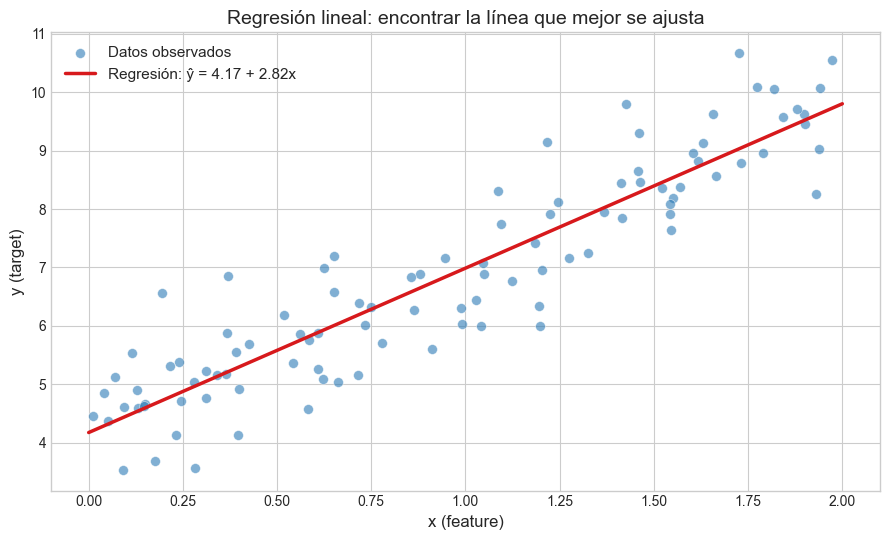

Parámetros reales:   θ₀ = 4.00, θ₁ = 3.00
Parámetros estimados: θ₀ = 4.17, θ₁ = 2.82


In [20]:
# --- Generate synthetic data with linear relationship + noise ---
m = 100  # number of samples
X_synth = 2 * np.random.rand(m, 1)         # feature: uniform [0, 2]
y_synth = 4 + 3 * X_synth + np.random.randn(m, 1) * 0.8  # y = 4 + 3x + noise

# Fit with sklearn for the plot
model_synth = LinearRegression()
model_synth.fit(X_synth, y_synth)
X_line = np.array([[0], [2]])
y_line = model_synth.predict(X_line)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(X_synth, y_synth, color=MAIN_COLOR, alpha=0.6, edgecolors='white',
           linewidth=0.5, s=50, label='Datos observados')
ax.plot(X_line, y_line, color=ACCENT_COLOR, linewidth=2.5,
        label=f'Regresión: ŷ = {model_synth.intercept_[0]:.2f} + {model_synth.coef_[0][0]:.2f}x')
ax.set_xlabel('x (feature)')
ax.set_ylabel('y (target)')
ax.set_title('Regresión lineal: encontrar la línea que mejor se ajusta')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f"Parámetros reales:   θ₀ = 4.00, θ₁ = 3.00")
print(f"Parámetros estimados: θ₀ = {model_synth.intercept_[0]:.2f}, θ₁ = {model_synth.coef_[0][0]:.2f}")

Los puntos azules son nuestros datos — cada uno con algo de ruido, como ocurre en la realidad. La línea roja es la que el modelo ha encontrado como "mejor ajuste". Los parámetros estimados se acercan bastante a los reales (θ₀ = 4, θ₁ = 3), pero no son exactos. Y no deberían serlo: el ruido existe, y el modelo lo sabe.

Ahora la pregunta importante: **¿qué significa "mejor ajuste"?** ¿Cómo decide el modelo que *esa* línea es mejor que cualquier otra? Para eso necesitamos hablar de la función de coste.

## 3. ¿Cómo "aprende"? La función de coste

Un modelo de ML necesita una forma de medir **qué tan mal** lo está haciendo. Esa medida es la **función de coste** (*cost function* o *loss function*). Entrenar el modelo consiste en encontrar los parámetros que minimizan esa función.

Para la regresión lineal, la función de coste estándar es el **Error Cuadrático Medio** (MSE, *Mean Squared Error*):

$$\text{MSE}(\boldsymbol{\theta}) = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{y}_i - y_i \right)^2$$

En palabras:
1. Para cada punto, calcula la diferencia entre la predicción ($\hat{y}_i$) y el valor real ($y_i$). Eso es el **error** o **residuo**.
2. Eleva cada error al cuadrado.
3. Calcula la media de todos esos errores al cuadrado.

### ¿Por qué elevar al cuadrado?

Dos razones principales:
- **Elimina los signos**: si un punto está por encima de la línea (error +2) y otro por debajo (error −2), sin cuadrado se cancelarían. El cuadrado garantiza que todos los errores suman.
- **Penaliza errores grandes desproporcionadamente**: un error de 4 no "cuesta" el doble que uno de 2, sino cuatro veces más (16 vs 4). Esto hace que el modelo se esfuerce especialmente por no equivocarse mucho en ningún punto.

### Visualizando la superficie de coste

Para nuestro caso simple con dos parámetros (θ₀ y θ₁), podemos visualizar el MSE como una superficie en 3D. Cada punto de la superficie representa el coste para una combinación de parámetros. El objetivo del entrenamiento es encontrar el **valle** — el punto más bajo.

/var/folders/4c/ng9_tzw93d72_zlfh1m9tr500000gn/T/ipykernel_44915/3234366814.py:52: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4c/ng9_tzw93d72_zlfh1m9tr500000gn/T/ipykernel_44915/3234366814.py:52: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/imbricadas/mambaforge/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/imbricadas/mambaforge/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


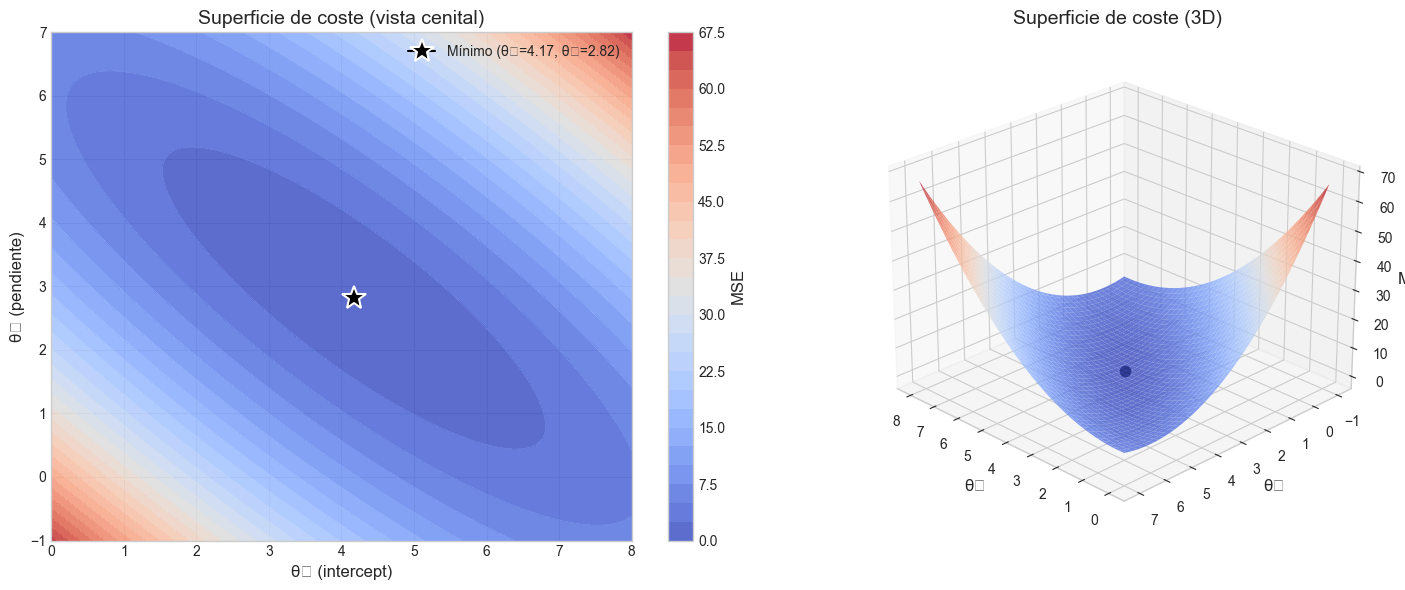

In [21]:
# --- Cost surface visualization ---
def compute_mse(X, y, theta0, theta1):
    """Compute MSE for given parameters."""
    predictions = theta0 + theta1 * X
    return np.mean((predictions - y) ** 2)

# Parameter grid
theta0_range = np.linspace(0, 8, 80)
theta1_range = np.linspace(-1, 7, 80)
T0, T1 = np.meshgrid(theta0_range, theta1_range)
MSE_grid = np.zeros_like(T0)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        MSE_grid[i, j] = compute_mse(X_synth.ravel(), y_synth.ravel(), T0[i, j], T1[i, j])

# Optimal parameters
theta0_opt = model_synth.intercept_[0]
theta1_opt = model_synth.coef_[0][0]
mse_opt = compute_mse(X_synth.ravel(), y_synth.ravel(), theta0_opt, theta1_opt)

# --- Two-panel figure: 3D surface + contour ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Contour plot
ax = axes[0]
contour = ax.contourf(T0, T1, MSE_grid, levels=30, cmap='coolwarm', alpha=0.85)
ax.contour(T0, T1, MSE_grid, levels=30, colors='white', linewidths=0.3, alpha=0.4)
ax.plot(theta0_opt, theta1_opt, marker='*', color='black', markersize=18,
        markeredgecolor='white', markeredgewidth=1.5, label=f'Mínimo (θ₀={theta0_opt:.2f}, θ₁={theta1_opt:.2f})')
fig.colorbar(contour, ax=ax, label='MSE')
ax.set_xlabel('θ₀ (intercept)')
ax.set_ylabel('θ₁ (pendiente)')
ax.set_title('Superficie de coste (vista cenital)')
ax.legend(loc='upper right', fontsize=10)

# 3D surface
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.plot_surface(T0, T1, MSE_grid, cmap='coolwarm', alpha=0.8,
                  edgecolor='none', antialiased=True)
ax3d.scatter([theta0_opt], [theta1_opt], [mse_opt], color='black', s=100,
             edgecolors='white', linewidth=1.5, zorder=5)
ax3d.set_xlabel('θ₀')
ax3d.set_ylabel('θ₁')
ax3d.set_zlabel('MSE')
ax3d.set_title('Superficie de coste (3D)')
ax3d.view_init(elev=25, azim=135)

# Remove the default second axes created by subplots
axes[1].remove()

plt.tight_layout()
plt.show()

La estrella negra marca el mínimo: la combinación de θ₀ y θ₁ que produce el menor error posible. En el *contour plot* (izquierda), las zonas más oscuras/azules indican menor coste. En la vista 3D (derecha), se ve claramente el "valle" al que queremos llegar.

Lo importante es que esta superficie es **convexa** — tiene un único mínimo global, sin mínimos locales donde quedarnos atrapados. Esta es una de las grandes ventajas de la regresión lineal: no importa por dónde empieces, si sigues bajando llegarás al mejor resultado posible.

Ahora viene la pregunta: **¿cómo llegamos a ese mínimo?**

## 4. Dos caminos para encontrar la solución

Existen dos enfoques fundamentales para encontrar los parámetros óptimos. Entender ambos es importante porque representan dos filosofías de optimización que se repiten en todo el ML.

### Camino 1: Ecuación Normal (solución analítica)

Si el MSE es una función convexa con un único mínimo, las matemáticas nos dan una fórmula cerrada para encontrarlo directamente:

$$\boldsymbol{\hat{\theta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

Esta es la **Ecuación Normal**. Se calcula en un solo paso, sin iteraciones. Es exacta.

- **Ventaja**: da la solución óptima directamente.
- **Limitación**: requiere invertir la matriz $\mathbf{X}^T\mathbf{X}$, cuyo coste computacional crece rápidamente con el número de features. Para datasets con miles de variables, puede volverse impracticable.

In [22]:
# --- Normal Equation: implemented from scratch ---
# Add bias column (column of ones)
X_b = np.c_[np.ones((m, 1)), X_synth]  # shape: (100, 2)

# Normal equation: θ = (XᵀX)⁻¹ Xᵀy
theta_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_synth

print("=== Ecuación Normal (desde cero) ===")
print(f"θ₀ (intercept) = {theta_normal[0][0]:.4f}")
print(f"θ₁ (pendiente) = {theta_normal[1][0]:.4f}")
print(f"\nRecordatorio — valores reales: θ₀ = 4.00, θ₁ = 3.00")

=== Ecuación Normal (desde cero) ===
θ₀ (intercept) = 4.1721
θ₁ (pendiente) = 2.8161

Recordatorio — valores reales: θ₀ = 4.00, θ₁ = 3.00


### Camino 2: Gradient Descent (descenso de gradiente)

La intuición es simple: imagina que estás en una montaña con niebla y quieres llegar al valle. No puedes ver el mínimo, pero sí puedes sentir la **pendiente** del suelo bajo tus pies. La estrategia es dar pasos en la dirección en que el terreno baja más rápido.

Eso es exactamente lo que hace el *gradient descent*:

1. Empieza con parámetros aleatorios.
2. Calcula el **gradiente** de la función de coste (la dirección de mayor subida).
3. Da un paso en la **dirección contraria** (para bajar).
4. Repite hasta que los parámetros dejen de cambiar significativamente.

La actualización en cada paso es:

$$\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \eta \cdot \nabla_{\theta} \text{MSE}(\boldsymbol{\theta})$$

Donde $\eta$ es el **learning rate** — el tamaño del paso. Si es muy grande, rebotamos sin converger. Si es muy pequeño, tardamos una eternidad.

In [23]:
# --- Gradient Descent: implemented from scratch ---
def gradient_descent(X, y, learning_rate=0.1, n_iterations=1000):
    """Batch gradient descent for linear regression."""
    m_samples = len(y)
    theta = np.random.randn(X.shape[1], 1) * 0.5  # random initialization
    history = {'theta': [theta.copy()], 'mse': []}

    for iteration in range(n_iterations):
        # Predictions
        predictions = X @ theta
        # Error
        errors = predictions - y
        # MSE
        mse = np.mean(errors ** 2)
        history['mse'].append(mse)
        # Gradient: (2/m) * Xᵀ(Xθ - y)
        gradients = (2 / m_samples) * X.T @ errors
        # Update
        theta = theta - learning_rate * gradients
        history['theta'].append(theta.copy())

    return theta, history


theta_gd, history_gd = gradient_descent(X_b, y_synth, learning_rate=0.1, n_iterations=200)

print("=== Gradient Descent (desde cero) ===")
print(f"θ₀ (intercept) = {theta_gd[0][0]:.4f}")
print(f"θ₁ (pendiente) = {theta_gd[1][0]:.4f}")

=== Gradient Descent (desde cero) ===
θ₀ (intercept) = 4.1708
θ₁ (pendiente) = 2.8172


/var/folders/4c/ng9_tzw93d72_zlfh1m9tr500000gn/T/ipykernel_44915/2968854345.py:32: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4c/ng9_tzw93d72_zlfh1m9tr500000gn/T/ipykernel_44915/2968854345.py:32: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()


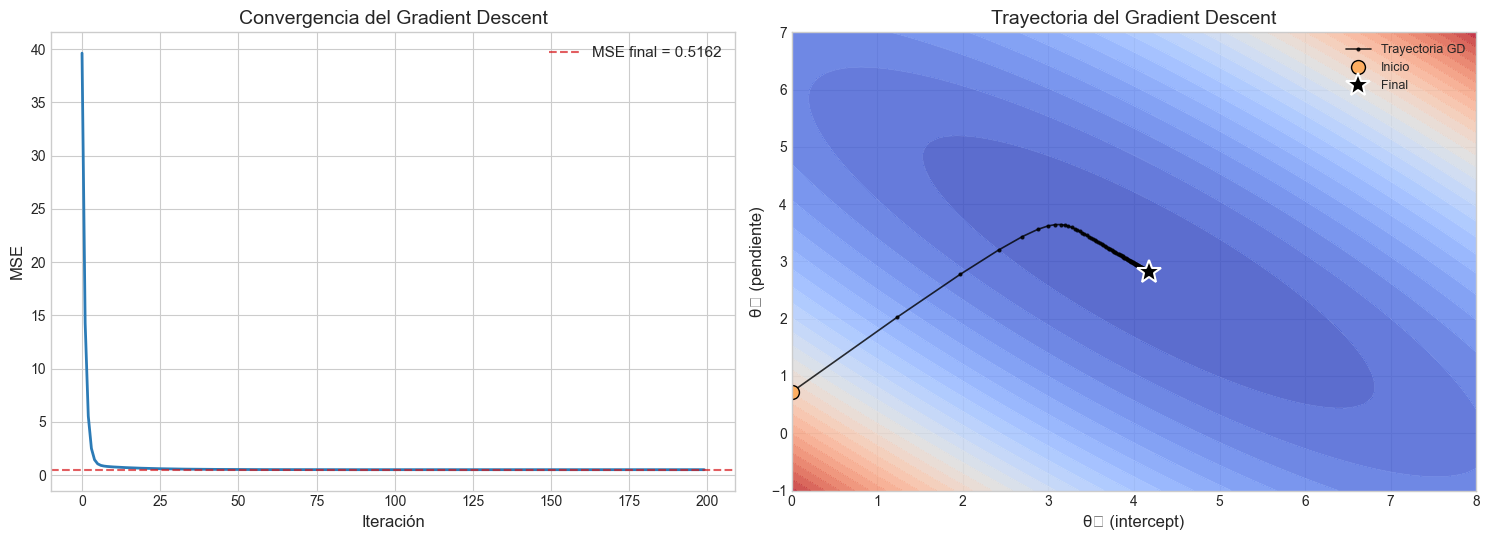

In [24]:
# --- Visualize convergence ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: MSE over iterations
ax = axes[0]
ax.plot(history_gd['mse'], color=MAIN_COLOR, linewidth=2)
ax.set_xlabel('Iteración')
ax.set_ylabel('MSE')
ax.set_title('Convergencia del Gradient Descent')
ax.axhline(y=history_gd['mse'][-1], color=ACCENT_COLOR, linestyle='--', alpha=0.7,
           label=f'MSE final = {history_gd["mse"][-1]:.4f}')
ax.legend()

# Right: path on contour plot
ax = axes[1]
ax.contourf(T0, T1, MSE_grid, levels=30, cmap='coolwarm', alpha=0.85)
ax.contour(T0, T1, MSE_grid, levels=30, colors='white', linewidths=0.3, alpha=0.4)

# Plot GD path
theta_path = np.array(history_gd['theta']).squeeze()
ax.plot(theta_path[:, 0], theta_path[:, 1], 'o-', color='black', markersize=2,
        linewidth=1.2, alpha=0.8, label='Trayectoria GD')
ax.plot(theta_path[0, 0], theta_path[0, 1], 'o', color=SECONDARY_COLOR,
        markersize=10, markeredgecolor='black', label='Inicio')
ax.plot(theta_path[-1, 0], theta_path[-1, 1], '*', color='black',
        markersize=18, markeredgecolor='white', markeredgewidth=1.5, label='Final')
ax.set_xlabel('θ₀ (intercept)')
ax.set_ylabel('θ₁ (pendiente)')
ax.set_title('Trayectoria del Gradient Descent')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

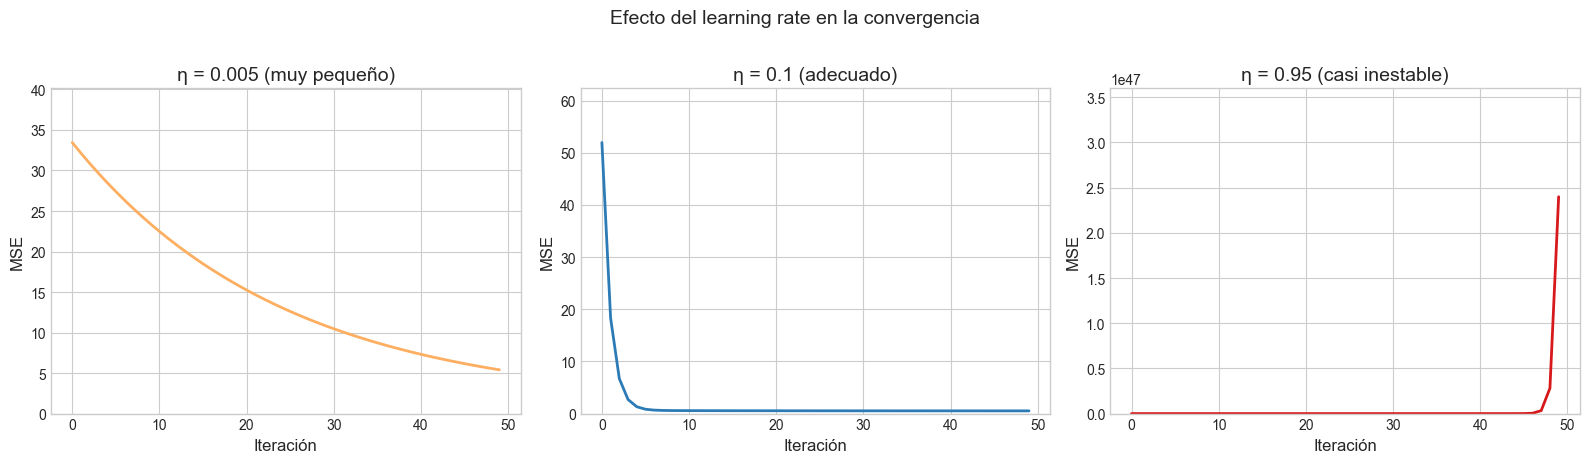

In [25]:
# --- Effect of learning rate ---
learning_rates = [0.005, 0.1, 0.95]
lr_labels = ['η = 0.005 (muy pequeño)', 'η = 0.1 (adecuado)', 'η = 0.95 (casi inestable)']
lr_colors = [SECONDARY_COLOR, MAIN_COLOR, ACCENT_COLOR]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for idx, (lr, label, color) in enumerate(zip(learning_rates, lr_labels, lr_colors)):
    _, hist = gradient_descent(X_b, y_synth, learning_rate=lr, n_iterations=50)
    ax = axes[idx]
    ax.plot(hist['mse'], color=color, linewidth=2)
    ax.set_xlabel('Iteración')
    ax.set_ylabel('MSE')
    ax.set_title(label)
    ax.set_ylim(0, max(hist['mse'][0] * 1.2, hist['mse'][-1] * 1.5, 15))

fig.suptitle('Efecto del learning rate en la convergencia', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

La gráfica de la izquierda muestra un *learning rate* demasiado pequeño: el modelo converge, pero con una lentitud exasperante. En el centro, un *learning rate* adecuado: convergencia rápida y estable. A la derecha, uno casi demasiado grande: el modelo oscila antes de (eventualmente) converger, o podría directamente divergir si subimos un poco más el valor.

En la práctica, encontrar el *learning rate* correcto es una de las decisiones más importantes al entrenar cualquier modelo con *gradient descent*.

### Comparación de ambos métodos

In [26]:
# --- Compare results ---
comparison = pd.DataFrame({
    'Método': ['Valores reales', 'Ecuación Normal', 'Gradient Descent', 'scikit-learn'],
    'θ₀ (intercept)': [4.0, theta_normal[0][0], theta_gd[0][0], model_synth.intercept_[0]],
    'θ₁ (pendiente)': [3.0, theta_normal[1][0], theta_gd[1][0], model_synth.coef_[0][0]]
}).set_index('Método')

comparison = comparison.round(4)
print("Comparación de métodos:")
print("=" * 50)
print(comparison.to_string())
print("\n→ Los tres métodos convergen al mismo resultado.")

Comparación de métodos:
                  θ₀ (intercept)  θ₁ (pendiente)
Método                                          
Valores reales            4.0000          3.0000
Ecuación Normal           4.1721          2.8161
Gradient Descent          4.1708          2.8172
scikit-learn              4.1721          2.8161

→ Los tres métodos convergen al mismo resultado.


Como era de esperar, ambos métodos (y scikit-learn internamente) llegan a la misma solución. La Ecuación Normal calcula la respuesta directamente; el Gradient Descent llega iterativamente. El resultado es el mismo porque la función de coste es convexa.

En modelos más complejos (redes neuronales, por ejemplo), no existe una ecuación normal. Solo queda el *gradient descent* y sus variantes. Por eso es tan importante entenderlo aquí, donde podemos verificar que funciona.

## 5. Caso práctico: California Housing

Pasemos de los datos sintéticos a un dataset real. **California Housing** contiene información sobre distritos censales de California en los años 90, con el objetivo de predecir el **valor mediano de las viviendas** (`MedHouseVal`, en cientos de miles de dólares).

Es un dataset clásico en ML, incluido en scikit-learn, y perfecto para nuestro propósito: lo suficientemente real para ser interesante, lo suficientemente manejable para explorarlo en un notebook.

In [27]:
# --- Load dataset ---
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f"Dimensiones: {df.shape[0]:,} observaciones, {df.shape[1]} columnas")
print(f"\nFeatures: {list(housing.feature_names)}")
print(f"Target: MedHouseVal (valor mediano de vivienda, en $100K)")
print("\n" + "=" * 60)
df.describe().round(3)

Dimensiones: 20,640 observaciones, 9 columnas

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal (valor mediano de vivienda, en $100K)



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


In [28]:
# --- Feature descriptions ---
feature_descriptions = {
    'MedInc': 'Ingreso mediano del distrito (en $10K)',
    'HouseAge': 'Edad mediana de las viviendas (años)',
    'AveRooms': 'Promedio de habitaciones por vivienda',
    'AveBedrms': 'Promedio de dormitorios por vivienda',
    'Population': 'Población del distrito',
    'AveOccup': 'Promedio de ocupantes por vivienda',
    'Latitude': 'Latitud del distrito',
    'Longitude': 'Longitud del distrito',
    'MedHouseVal': 'Valor mediano de vivienda ($100K) — TARGET'
}

desc_df = pd.DataFrame.from_dict(feature_descriptions, orient='index', columns=['Descripción'])
desc_df.index.name = 'Variable'
print(desc_df.to_string())

                                            Descripción
Variable                                               
MedInc           Ingreso mediano del distrito (en $10K)
HouseAge           Edad mediana de las viviendas (años)
AveRooms          Promedio de habitaciones por vivienda
AveBedrms          Promedio de dormitorios por vivienda
Population                       Población del distrito
AveOccup             Promedio de ocupantes por vivienda
Latitude                           Latitud del distrito
Longitude                         Longitud del distrito
MedHouseVal  Valor mediano de vivienda ($100K) — TARGET


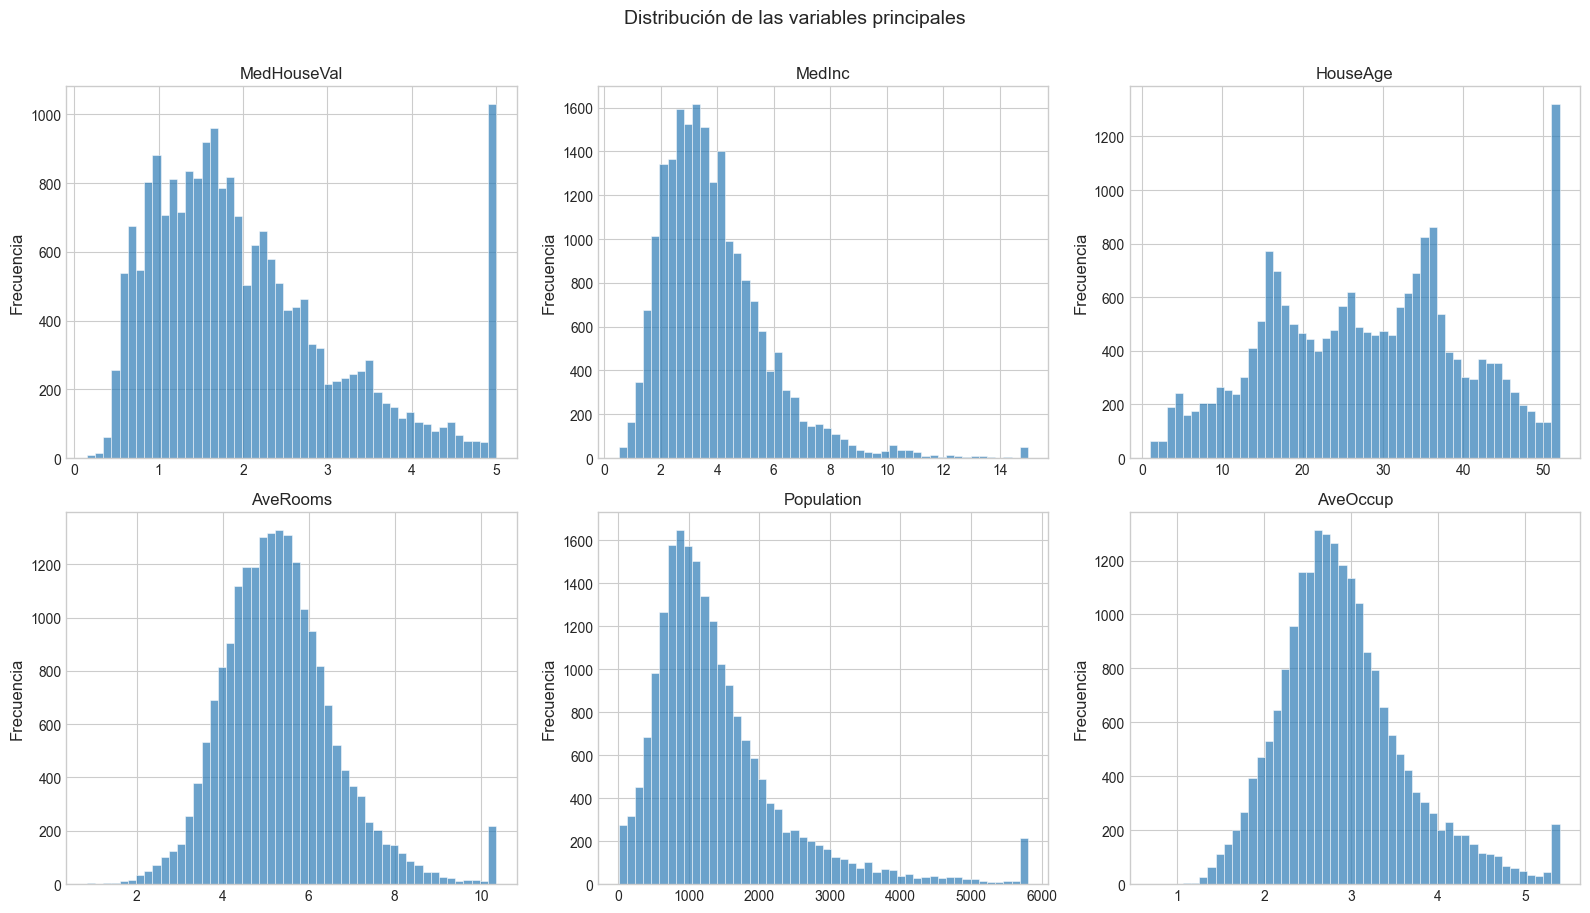

In [29]:
# --- Distribution of key variables ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

plot_vars = ['MedHouseVal', 'MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup']

for idx, var in enumerate(plot_vars):
    ax = axes[idx // 3][idx % 3]
    data = df[var]
    # Clip outliers for better visualization on some variables
    if var in ['AveRooms', 'Population', 'AveOccup']:
        data = data.clip(upper=data.quantile(0.99))
    ax.hist(data, bins=50, color=MAIN_COLOR, alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.set_title(var, fontsize=12)
    ax.set_ylabel('Frecuencia')

fig.suptitle('Distribución de las variables principales', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

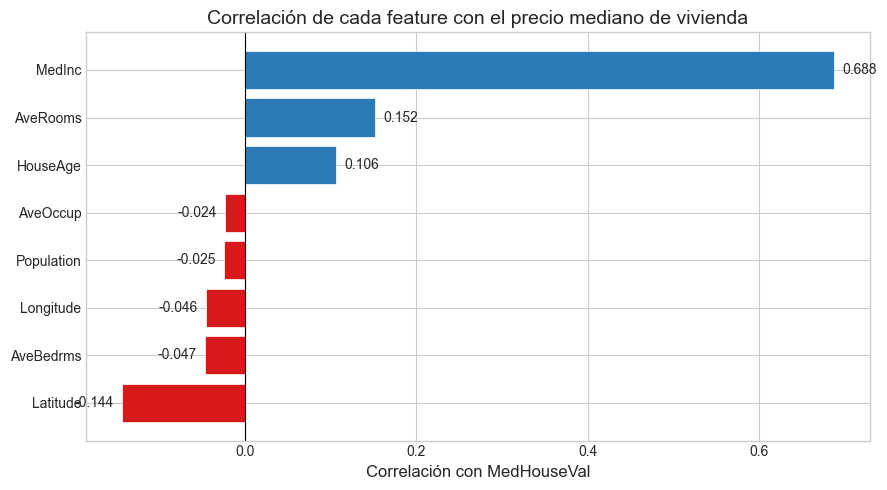


→ MedInc (ingreso mediano) tiene la correlación más fuerte: 0.688
  Esto tiene sentido: los distritos con mayores ingresos tienen viviendas más caras.


In [30]:
# --- Correlations with target ---
correlations = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [ACCENT_COLOR if v < 0 else MAIN_COLOR for v in correlations.values]
bars = ax.barh(correlations.index, correlations.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Correlación con MedHouseVal')
ax.set_title('Correlación de cada feature con el precio mediano de vivienda')
ax.axvline(x=0, color='black', linewidth=0.8)

# Add value labels
for bar, val in zip(bars, correlations.values):
    ax.text(val + 0.01 * np.sign(val), bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', ha='left' if val > 0 else 'right', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n→ MedInc (ingreso mediano) tiene la correlación más fuerte: {correlations['MedInc']:.3f}")
print("  Esto tiene sentido: los distritos con mayores ingresos tienen viviendas más caras.")

In [31]:
# --- Train the model with scikit-learn ---
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Modelo entrenado.")
print(f"Datos de entrenamiento: {X_train.shape[0]:,} observaciones")
print(f"Datos de test:          {X_test.shape[0]:,} observaciones")

Modelo entrenado.
Datos de entrenamiento: 16,512 observaciones
Datos de test:          4,128 observaciones


In [32]:
# --- Evaluation metrics ---
metrics = {
    'Métrica': ['R² (coeficiente de determinación)', 'MSE (error cuadrático medio)',
                'RMSE (raíz del MSE)', 'MAE (error absoluto medio)'],
    'Train': [
        r2_score(y_train, y_pred_train),
        mean_squared_error(y_train, y_pred_train),
        np.sqrt(mean_squared_error(y_train, y_pred_train)),
        mean_absolute_error(y_train, y_pred_train)
    ],
    'Test': [
        r2_score(y_test, y_pred_test),
        mean_squared_error(y_test, y_pred_test),
        np.sqrt(mean_squared_error(y_test, y_pred_test)),
        mean_absolute_error(y_test, y_pred_test)
    ]
}

metrics_df = pd.DataFrame(metrics).set_index('Métrica').round(4)
print(metrics_df.to_string())

                                    Train    Test
Métrica                                          
R² (coeficiente de determinación)  0.6126  0.5758
MSE (error cuadrático medio)       0.5179  0.5559
RMSE (raíz del MSE)                0.7197  0.7456
MAE (error absoluto medio)         0.5286  0.5332


### ¿Qué significan estas métricas?

- **R² (coeficiente de determinación)**: mide qué proporción de la variabilidad del precio es explicada por el modelo. Un R² de 0.60 significa que el modelo explica ~60% de la variación en precios. El otro 40% es ruido, relaciones no lineales, o información que el modelo no tiene.

- **RMSE (raíz del error cuadrático medio)**: está en las mismas unidades que el target (cientos de miles de dólares). Un RMSE de ~0.73 significa que, en promedio, el modelo se equivoca por unos $73,000. ¿Es mucho? Depende del contexto: para una decisión de inversión inmobiliaria de millones, podría ser aceptable. Para una familia buscando casa, no tanto.

- **MAE (error absoluto medio)**: similar al RMSE pero sin penalizar tanto los errores grandes. Suele dar un valor más bajo porque es menos sensible a los *outliers*.

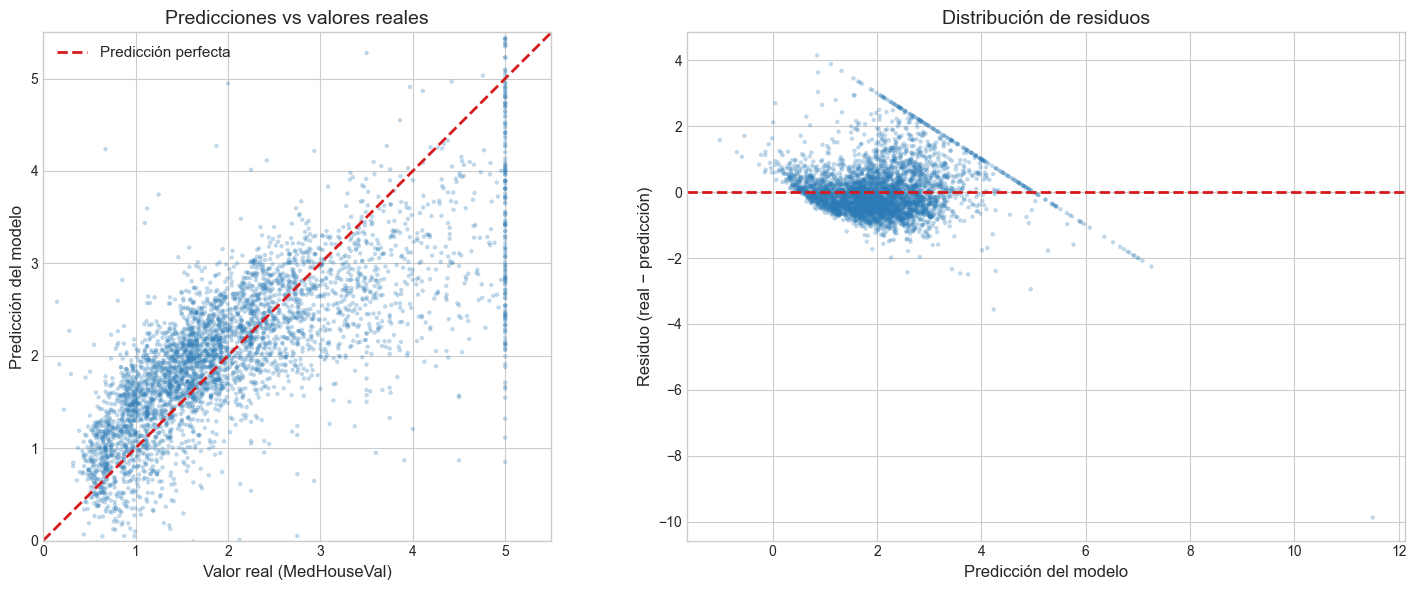

In [33]:
# --- Predictions vs actual values ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: predicted vs actual
ax = axes[0]
ax.scatter(y_test, y_pred_test, alpha=0.3, s=10, color=MAIN_COLOR, edgecolors='none')
lims = [0, 5.5]
ax.plot(lims, lims, color=ACCENT_COLOR, linewidth=2, linestyle='--', label='Predicción perfecta')
ax.set_xlabel('Valor real (MedHouseVal)')
ax.set_ylabel('Predicción del modelo')
ax.set_title('Predicciones vs valores reales')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend()
ax.set_aspect('equal')

# Residuals
ax = axes[1]
residuals = y_test - y_pred_test
ax.scatter(y_pred_test, residuals, alpha=0.3, s=10, color=MAIN_COLOR, edgecolors='none')
ax.axhline(y=0, color=ACCENT_COLOR, linewidth=2, linestyle='--')
ax.set_xlabel('Predicción del modelo')
ax.set_ylabel('Residuo (real − predicción)')
ax.set_title('Distribución de residuos')

plt.tight_layout()
plt.show()

Dos observaciones importantes de estas gráficas:

1. **Predicciones vs reales** (izquierda): si el modelo fuera perfecto, todos los puntos estarían sobre la línea diagonal roja. Los puntos se dispersan bastante, confirmando que el modelo captura la tendencia general pero dista de ser perfecto. Nótese la línea horizontal de puntos en el valor real de ~5.0 — eso es un *cap* (límite artificial) en los datos originales.

2. **Residuos** (derecha): en un modelo ideal, los residuos deberían distribuirse aleatoriamente alrededor del cero. Aquí vemos un patrón: para predicciones bajas los residuos son más dispersos, y hay una concentración de residuos negativos para predicciones altas. Esto sugiere que **la relación no es puramente lineal** — hay patrones que el modelo no puede capturar.

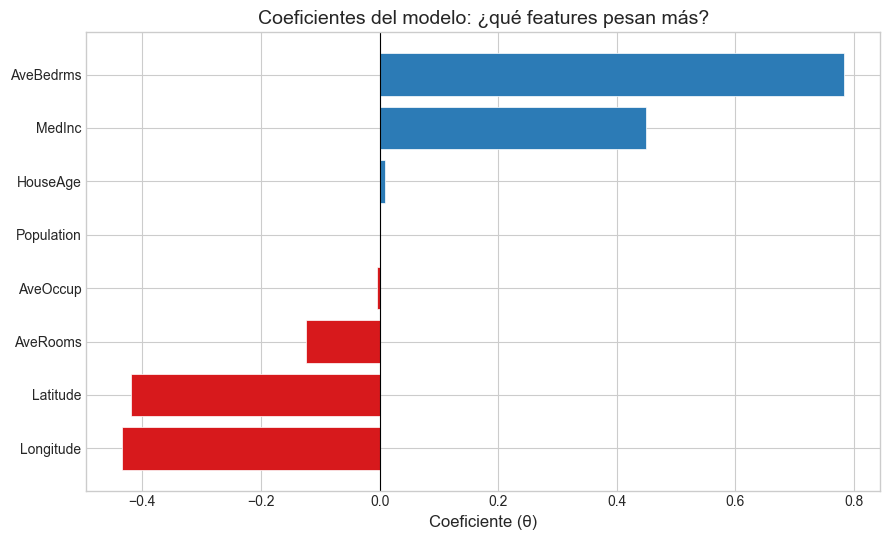


Coeficientes ordenados por magnitud absoluta:
  ↑ AveBedrms     +0.7831
  ↑ MedInc        +0.4487
  ↓ Longitude     -0.4337
  ↓ Latitude      -0.4198
  ↓ AveRooms      -0.1233
  ↑ HouseAge      +0.0097
  ↓ AveOccup      -0.0035
  ↓ Population    -0.0000

  Intercept (θ₀): -37.0233


In [34]:
# --- Feature importance: model coefficients ---
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': model.coef_
}).sort_values('Coeficiente', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [ACCENT_COLOR if v < 0 else MAIN_COLOR for v in coef_df['Coeficiente']]
ax.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors,
        edgecolor='white', linewidth=0.5)
ax.set_xlabel('Coeficiente (θ)')
ax.set_title('Coeficientes del modelo: ¿qué features pesan más?')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nCoeficientes ordenados por magnitud absoluta:")
print("=" * 50)
coef_sorted = coef_df.copy()
coef_sorted['|Coeficiente|'] = coef_sorted['Coeficiente'].abs()
coef_sorted = coef_sorted.sort_values('|Coeficiente|', ascending=False)
for _, row in coef_sorted.iterrows():
    direction = '↑' if row['Coeficiente'] > 0 else '↓'
    print(f"  {direction} {row['Feature']:12s}  {row['Coeficiente']:+.4f}")
print(f"\n  Intercept (θ₀): {model.intercept_:.4f}")

### Interpretando los coeficientes

Los coeficientes nos dicen la historia que el modelo ha aprendido de los datos:

- **MedInc** tiene el coeficiente positivo más grande por un margen considerable. Esto significa que, según el modelo, el ingreso mediano del distrito es con diferencia el predictor más fuerte del valor de la vivienda. ¿Tiene sentido? Absolutamente — los barrios con mayores ingresos tienen casas más caras.

- **Latitude** y **Longitude** aparecen con coeficientes significativos. Esto captura la geografía: las viviendas cerca de la costa (longitudes más negativas, latitudes más bajas en el sur de California) tienden a ser más caras.

- **AveOccup** tiene un coeficiente negativo: mayor ocupación por vivienda se asocia con menor valor.

**Nota importante sobre los coeficientes**: como las features tienen escalas distintas (MedInc va de 0 a 15, Population puede ser de miles), no podemos comparar directamente la magnitud de los coeficientes como medida de "importancia". Para eso haría falta estandarizar las variables primero. Aún así, la dirección (positivo/negativo) y el orden relativo nos dan información valiosa.

## 6. Limitaciones y reflexión

---

### Limitaciones técnicas

La regresión lineal es potente por su simplicidad, pero esa misma simplicidad impone restricciones importantes:

- **Asume una relación lineal** entre las features y el target. Si la relación real es curva, exponencial, o tiene interacciones complejas, el modelo no puede capturarla. Vimos indicios de esto en los residuos.

- **Sensible a outliers**: al elevar los errores al cuadrado, un solo punto atípico puede distorsionar toda la línea de regresión. Esto se nota especialmente en datasets pequeños.

- **Multicolinealidad**: si dos features están altamente correlacionadas entre sí (por ejemplo, número de habitaciones y superficie), los coeficientes se vuelven inestables — pequeños cambios en los datos producen grandes cambios en los pesos. El modelo sigue funcionando para predecir, pero los coeficientes pierden interpretabilidad.

- **No captura interacciones**: el efecto de cada variable se modela de forma independiente. En la realidad, variables como ubicación e ingreso interactúan de formas que el modelo no puede representar.

---

### Reflexión sobre el mundo real

Acabamos de construir un modelo que predice el precio mediano de una vivienda. Un ejercicio técnico aparentemente inocuo. Pero pensemos un momento en qué pasa cuando este tipo de modelos salen del notebook y entran en el mundo real:

**¿Y si se usara para decidir quién recibe un préstamo hipotecario? ¿O para asignar recursos públicos?**

Los coeficientes del modelo reflejan patrones históricos del mercado inmobiliario de California en los años 90. Esos patrones incluyen décadas de segregación residencial, discriminación en préstamos (*redlining*), y desigualdad económica sistémica. **El modelo no crea esos sesgos, pero los perpetúa.** Si un sistema automatizado usa un modelo así para tomar decisiones, está codificando la desigualdad histórica en decisiones presentes.

Consideremos algo más sutil: **elegir qué variables incluir en el modelo ya es una decisión humana con consecuencias.** Si incluimos la latitud y longitud como features — como hicimos aquí — estamos potencialmente codificando segregación racial en la predicción, porque la distribución geográfica de la riqueza en California no es accidental. Refleja políticas históricas de planificación urbana que discriminaron a comunidades enteras.

Nada de esto invalida el modelo como herramienta. Pero sí nos obliga a preguntarnos:

- ¿Quién se ve afectado por las predicciones?
- ¿Qué decisiones se van a tomar con estos resultados?
- ¿Los datos históricos representan el mundo como **es** o como **debería ser**?

---

### Conexión con adopción de IA en organizaciones

Antes de desplegar cualquier modelo en una organización — por simple que parezca, incluyendo una regresión lineal — necesitamos entender tres cosas:

1. **Qué datos lo alimentan**: ¿de dónde vienen? ¿Qué sesgos de recopilación tienen? ¿Qué poblaciones están sub o sobre-representadas?
2. **Qué patrones captura**: ¿los coeficientes reflejan relaciones causales o simplemente correlaciones históricas? ¿Estamos cómodos con lo que el modelo ha "aprendido"?
3. **Qué decisiones va a influir**: ¿el modelo genera un informe que alguien revisa, o alimenta un sistema automatizado que actúa sin intervención humana?

La regresión lineal, con su transparencia e interpretabilidad, es paradójicamente uno de los mejores modelos para empezar estas conversaciones. Puedes abrir la "caja" y ver exactamente qué hay dentro. En modelos más complejos, esa transparencia desaparece — pero las preguntas siguen siendo las mismas.

## 7. Recursos para profundizar

---

- **Géron, A. (2022).** *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*, 3rd Edition. **Capítulo 4: Training Models.** La referencia práctica más completa para entender regresión lineal y sus variantes en el contexto de ML moderno.

- **Hastie, T., Tibshirani, R., & Friedman, J. (2009).** *The Elements of Statistical Learning*, 2nd Edition. **Capítulo 3: Linear Methods for Regression.** La referencia académica clásica. Lectura densa pero rigurosa. Disponible gratuitamente: [https://hastie.su.domains/ElemStatLearn/](https://hastie.su.domains/ElemStatLearn/)

- **Molnar, C. (2022).** *Interpretable Machine Learning.* Un recurso excelente para entender qué significan realmente los coeficientes y predicciones de un modelo, y cómo comunicarlos. Disponible gratuitamente: [https://christophm.github.io/interpretable-ml-book/](https://christophm.github.io/interpretable-ml-book/)

- **Blog post (próximamente):** "Linear Regression is not as simple as you think" — un artículo donde exploraremos con más profundidad las sutilezas que este notebook solo menciona de pasada: multicolinealidad, regularización, y los errores más comunes al interpretar coeficientes.

---

*Este notebook es parte de una serie sobre fundamentos de ML desde la perspectiva de adopción responsable de IA en organizaciones.*